In [1]:
import numpy as np
import pandas as pd
import joblib

In [2]:
data=pd.read_csv('5.urldata.csv')
data.head()

,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,graphicriver.net,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,0
1,ecnavi.jp,0,0,1,1,1,0,0,0,0,1,1,1,0,0,1,0,0
2,hubpages.com,0,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0,0
3,extratorrent.cc,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
4,icicibank.com,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X = data.copy()

y=X.pop('Label')

X = data.drop(columns=['Domain','Label'])

X_train, X_valid, y_train, y_valid = \
    train_test_split(X, y, stratify=y,train_size=0.75)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
input_shape = [X_train.shape[1]]
print("input shape is",input_shape)
X.head()
joblib.dump(scaler,"scaler.pkl")

from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.BatchNormalization(input_shape=input_shape),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid'),
])

input shape is [16]


C:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\normalization\batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [4]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [4]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy',keras.metrics.Precision(),keras.metrics.Recall()],
    
)

In [7]:
early_stopping = keras.callbacks.EarlyStopping(
    patience=20,
    min_delta=0.01,
    restore_best_weights=True,
)
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=512,
    epochs=200,
    callbacks=[early_stopping],
)


Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 161ms/step - binary_accuracy: 0.7133 - loss: 0.6672 - precision: 0.7649 - recall: 0.6448 - val_binary_accuracy: 0.5408 - val_loss: 0.6121 - val_precision: 0.5214 - val_recall: 0.9960
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - binary_accuracy: 0.7985 - loss: 0.4564 - precision: 0.8459 - recall: 0.7246 - val_binary_accuracy: 0.5024 - val_loss: 0.6389 - val_precision: 0.5012 - val_recall: 0.9992
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - binary_accuracy: 0.8114 - loss: 0.4190 - precision: 0.8846 - recall: 0.7223 - val_binary_accuracy: 0.5024 - val_loss: 0.6675 - val_precision: 0.5012 - val_recall: 0.9992
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - binary_accuracy: 0.8052 - loss: 0.4098 - precision: 0.8586 - recall: 0.7334 - val_binary_accuracy: 0.5028 - val_loss: 0.6694 - val_precision: 0.5014 - val_recall: 1.0000
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - binary_accuracy: 0.8213 - loss: 0.3931 - precisi

In [5]:
history_df = pd.DataFrame(history.history)
history_df.loc[0:, ['loss', 'val_loss']].plot()
history_df.loc[0:, ['binary_accuracy', 'val_binary_accuracy']].plot()

print(f"Best Validation Loss: {history_df['val_loss'].min()}" +\
      f"\nBest Validation Accuracy: {history_df['val_binary_accuracy'].max()}"+\
      f"\nBest Recall: {history_df['val_recall'].max()}" +\
      f"\nBest Precision: {history_df['val_precision'].max()}"
)

NameError: name 'history' is not defined

In [ ]:
import re
from urllib.parse import urlparse

def has_ip_address(url):
    return 1 if re.search(r'\b(?:[0-9]{1,3}\.){3}[0-9]{1-3}\b',url) else 0

def has_at_symbol(url):
    return 1 if '@' in url else 0

def get_url_length(url):
    return 1 if len(url) < 54 else 0

def get_url_depth(url):
    path=urlparse(url).path
    return path.count('/')
    
def has_redirection(url):
    return 1 if '//' in urlparse(url).path else 0

def has_https_in_domain(url):
    domain=urlparse(url).netloc
    return 1 if 'https' in domain else 0

def is_tiny_url(url):
    tiny_domain=["bit.ly", "goog.gl", "tinyurl.com", "ow.ly", "t.co"]
    domain = urlparse(url).netloc
    return 1 if domain in tiny_domain else 0

def has_prefix_suffix(url):
    domain= urlparse(url).netloc
    return 1 if '-' in domain else 0

import socket
from functools import lru_cache

@lru_cache(maxsize=10000)
def check_dns_record(domain):
    try:
        socket.gethostbyname(domain)
        return 1
    except socket.error:
        return 0

ranked_domains = pd.read_csv("tranco_Z38YG.csv")
def get_web_traffic(domain):
    return 1 if domain in ranked_domains.values else 0

import whois
from datetime import datetime

def get_domain_age(domain):
    try:
        domain_info = whois.whois(domain)
        creation_date = domain_info.creation_date
        if isinstance(creation_date, list):
            creation_date = creation_date[0]
        age_in_days = (datetime.now() - creation_date).days
        return 1 if age_in_days >= 365 else 0
    except Exception:
        return 0

def get_domain_end_period(domain):
    try:
        domain_info = whois.whois(domain)
        expiration_date = domain_info.expiration_date
        if isinstance(expiration_date, list):
            expiration_date = expiration_date[0]
        days_to_expire = (expiration_date - datetime.now()).days
        return 1 if days_to_expire >= 180 else 0
    except Exception:
        return 0

from bs4 import BeautifulSoup

def uses_iframe(url,check_html=False):
    if not check_html:
        return 0
    try:
        response = requests.get(url, timeout=3)
        soup = BeautifulSoup(response.content, 'html.parser')
        return 1 if soup.find_all('iframe') else 0
    except Exception:
        return 0


def has_mouse_over_effect(url):
    try:
        response = requests.get(url, timeout=5)
        html = response.text
        return 1 if 'onmouseover' in html else 0
    except Exception:
        return 0

def allows_right_click(url):
    return 1

def has_web_forwards(url):
    try:
        response = requests.get(url, allow_redirects=True,timeout=3)
        redirect_count=len(response.history)
        return 1 if redirect_count >= 3 else 0
    except Exception:
        return 0

    
def extract_features(url):
    url = url.rstrip('/')
    domain = urlparse(url).netloc
    features=[has_ip_address(url),has_at_symbol(url),get_url_length(url),
              get_url_depth(url),has_redirection(url),has_https_in_domain(url),
              is_tiny_url(url),has_prefix_suffix(url), check_dns_record(domain),
              get_web_traffic(domain),get_domain_age(domain),get_domain_end_period(domain),
              uses_iframe(url,check_html=False),has_mouse_over_effect(url),allows_right_click(url),
              has_web_forwards(url)]
    return features

In [ ]:
url = "https://web.whatsapp.com/"
import numpy as np
# Extract features
features = np.array(extract_features(url))
features=features.reshape(1,-1)
features = scaler.transform(features)
prediction = model.predict(features)
is_phishing = prediction[0][0] > 0.5

if is_phishing:
    print("the url is likely a phishing site.")
else:
    print("The URL is likely legitimate.")

In [12]:
# model.save('phishing_model.keras')

PermutationExplainer explainer: 2501it [26:53,  1.55it/s]                                                              


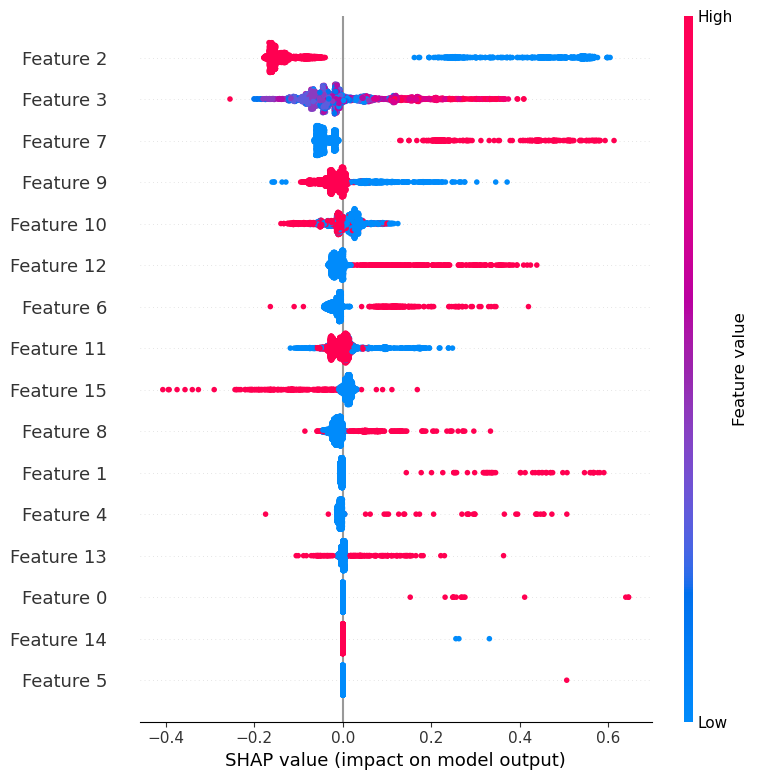

In [13]:
import shap

# Initialize the SHAP explainer
explainer = shap.Explainer(model, X_train)

# Compute SHAP values for the validation set
shap_values = explainer(X_valid)

# Visualize feature importance
shap.summary_plot(shap_values, X_valid)


In [14]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenize the URLs
tokenizer = Tokenizer(char_level=True)  # Character-level tokenization
tokenizer.fit_on_texts(data['Domain'])

# Convert URLs to sequences
X_seq = tokenizer.texts_to_sequences(data['Domain'])

# Pad sequences to a fixed length
max_length = 75  # Based on URL length analysis
X_padded = pad_sequences(X_seq, maxlen=max_length, padding='post')

# Train-Test Split
X_train, X_valid, y_train, y_valid = train_test_split(X_padded, y, stratify=y, train_size=0.75)


In [15]:
model_cnn = keras.Sequential([
    layers.Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=64, input_length=max_length),
    layers.Conv1D(64, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(128, kernel_size=3, activation='relu'),
    layers.GlobalMaxPooling1D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid'),
])

# Compile Model
model_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train Model
history_cnn = model_cnn.fit(X_train, y_train, validation_data=(X_valid, y_valid), batch_size=64, epochs=10)

# Evaluate
cnn_accuracy = model_cnn.evaluate(X_valid, y_valid)[1]
print(f'CNN Validation Accuracy: {cnn_accuracy:.4f}')


C:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 71s 54ms/step - accuracy: 0.7140 - loss: 0.5883 - val_accuracy: 0.8908 - val_loss: 0.2760
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9153 - loss: 0.2289 - val_accuracy: 0.9588 - val_loss: 0.1366
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9734 - loss: 0.0872 - val_accuracy: 0.9760 - val_loss: 0.0918
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9872 - loss: 0.0446 - val_accuracy: 0.9844 - val_loss: 0.0835
Epoch 5/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9935 - loss: 0.0294 - val_accuracy: 0.9812 - val_loss: 0.0828
Epoch 6/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9960 - loss: 0.0233 - val_accuracy: 0.9848 - val_loss: 0.0714
Epoch 7/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9975 - loss: 0.0118 - val_accuracy: 0.9764 - val_loss: 0.0960
Epoch 8/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9970 - loss: 0.0160 - val_acc

In [16]:
model_lstm = keras.Sequential([
    layers.Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=64, input_length=max_length),
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(64),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid'),
])

# Compile Model
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train Model
history_lstm = model_lstm.fit(X_train, y_train, validation_data=(X_valid, y_valid), batch_size=64, epochs=10)

# Evaluate
lstm_accuracy = model_lstm.evaluate(X_valid, y_valid)[1]
print(f'LSTM Validation Accuracy: {lstm_accuracy:.4f}')


Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 33s 139ms/step - accuracy: 0.4957 - loss: 0.6937 - val_accuracy: 0.5012 - val_loss: 0.6931
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 14s 120ms/step - accuracy: 0.5081 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step - accuracy: 0.4856 - loss: 0.6935 - val_accuracy: 0.5000 - val_loss: 0.6939
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 14s 118ms/step - accuracy: 0.5039 - loss: 0.6933 - val_accuracy: 0.5012 - val_loss: 0.6932
Epoch 5/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 14s 117ms/step - accuracy: 0.5026 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6955
Epoch 6/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step - accuracy: 0.5061 - loss: 0.6946 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - accuracy: 0.4901 - loss: 0.6985 - val_accuracy: 0.5028 - val_loss: 0.6932
Epoch 8/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 15s 124ms/step - accuracy: 0.4975 - loss: 0

In [21]:
def predict_url(url, model):
    # Convert URL to numerical sequence
    seq = tokenizer.texts_to_sequences([url])
    seq_padded = pad_sequences(seq, maxlen=max_length, padding='post')

    # Make prediction
    prediction = model.predict(seq_padded)[0][0]
    return "Phishing" if prediction > 0.5 else "Legitimate"

# Test Example
url = "http://paypal-security.com/login"
print("CNN Prediction:", predict_url(url, model_cnn))
print("LSTM Prediction:", predict_url(url, model_lstm))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
CNN Prediction: Phishing
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
LSTM Prediction: Legitimate


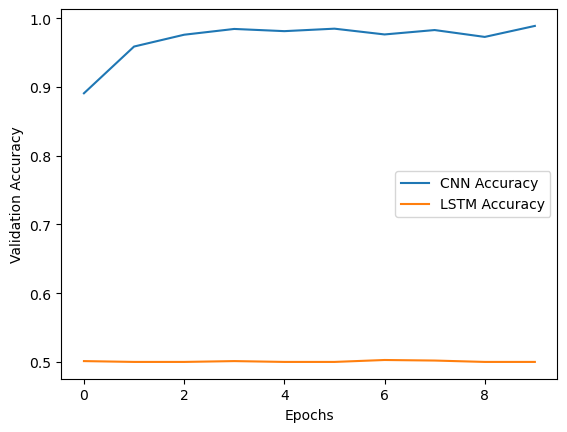

In [18]:
import matplotlib.pyplot as plt

# Plot CNN vs. LSTM Accuracy
plt.plot(history_cnn.history['val_accuracy'], label="CNN Accuracy")
plt.plot(history_lstm.history['val_accuracy'], label="LSTM Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()
